In [1]:
from sensor_core import SensorManager
import numpy as np

In [2]:
# USER DEFINED PARAMS
ser_channel_key = ["cam0"]                    # Names of serial channels
plot_channel_key = [["cam0"]]                 # Names and gridplot arrangement of plot channels
commport = None                               # Name of comm port
baudrate = None                               # bits/second

In [3]:
# Custom Serial Acquisition Function
def acquire_data(ser, frame_shape):
    """ serial acquisition function handler. All parameters are internally generated
    Must include the following parameters:
    :param ser: serial port
    :param window_size: number of frames to capture before passing to shared memory object. Default 1
    :param num_channel: number of channels to capture. 
    """
    channel_data = np.random.rand(frame_shape[0], frame_shape[1], 1)*255
    channel_data = channel_data.astype(np.uint8)
    return channel_data

In [4]:
# Instantiate Sensor Manager class
sm = SensorManager(ser_channel_key=ser_channel_key,
                   plot_channel_key=plot_channel_key,
                   commport=commport, 
                   baudrate=baudrate,
                   dtype=np.uint8,
                   data_mode='image',
                   frame_shape=(640,480,1),    # Width, Height, num_channels
                   rotate_frames=256,
                   start_stream_ingest=True)

In [5]:
# Create 'update process' to handle acquired data
update_process = sm.update_data_process(save_data=True, 
                            filepath='./serial_db.sqlite3',
                            virtual_ser_port = True,
                            func=acquire_data)
# Create 'plot process' to handle plotting. Returns plot object as well
plot_process, plot = sm.setup_plotting_process()

Image(value=b'\x89PNG\r\n\x1a\n\x00\x00\x00\rIHDR\x00\x00\x01,\x00\x00\x007\x08\x06\x00\x00\x00\xb6\x1bw\x99\x…

Valid,Device,Type,Backend,Driver
✅,Intel(R) UHD Graphics 770,IntegratedGPU,Vulkan,101.7076
✅ (default),NVIDIA RTX A1000 6GB Laptop GPU,DiscreteGPU,Vulkan,581.60
✅,Intel(R) UHD Graphics,IntegratedGPU,D3D12,
✅,NVIDIA RTX A1000 6GB Laptop GPU,DiscreteGPU,D3D12,
❗ limited,Microsoft Basic Render Driver,CPU,D3D12,
❌,Intel(R) UHD Graphics 770,IntegratedGPU,OpenGL,4.6.0 - Build 32.0.101.7076


To silence this warning, use a fully namespaced name.


RFBOutputContext()

In [6]:
sm.static_args_dict

{'ser_channel_key': ['cam0'],
 'plot_channel_key': [['cam0']],
 'commport': None,
 'baudrate': None,
 'shm_name': '/sensor_ring',
 'shape': (640, 480, 1),
 'dtype': numpy.uint8,
 'ring_capacity': 4096,
 'data_mode': 'image',
 'frame_shape': (640, 480, 1),
 'plot_target_fps': 60.0,
 'plot_catch_up_max': 2048,
 'plot_catchup_boost': 2.5}

In [7]:
# Start update process, start plotting process
## Recommended to use in-built start_process function to avoid Windows OS issues
sm.start_process(update_process)
sm.start_process(plot_process)

JupyterRenderCanvas(css_height='300.0px', css_width='500.0px')
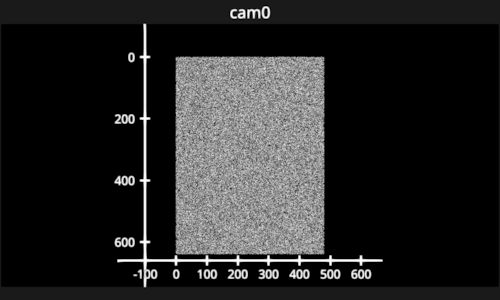

In [8]:
# Show plot
plot.show()

In [9]:
# Get metrics snapshot
sm.get_metrics()

{'writer': {'init': True,
  'writer_alive': True,
  'writer_start_unix': 1770302930.12225,
  'writer_watch_bins': ['C:\\Users\\lukep\\Downloads\\sensor_core2\\sensor_core\\examples\\serial_stream_a.bin',
   'C:\\Users\\lukep\\Downloads\\sensor_core2\\sensor_core\\examples\\serial_stream_b.bin'],
  'writer_watch_seals': ['C:\\Users\\lukep\\Downloads\\sensor_core2\\sensor_core\\examples\\serial_stream_a.bin.seal',
   'C:\\Users\\lukep\\Downloads\\sensor_core2\\sensor_core\\examples\\serial_stream_b.bin.seal'],
  'writer_ring': {'name': '/sensor_ring',
   'capacity': 4096,
   'shape': (640, 480, 1),
   'dtype': 'uint8'},
  'writer_active_bin': 'C:\\Users\\lukep\\Downloads\\sensor_core2\\sensor_core\\examples\\serial_stream_a.bin',
  'writer_total_frames': 256,
  'writer_total_bytes': 78647296,
  'writer_rotations': 2,
  'writer_fps_estimate': 267.1081677704344,
  'writer_last_rotation_unix': 1770302939.05344,
  'writer_updated_unix': 1770302939.05344,
  'writer_seal_exists': [True, True],